In [1]:
import pandas as pd

In [2]:
df1=pd.read_csv("insurance.csv")

In [3]:
df1.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# df.columns
# df['sex'].replace({"female":1})
df=df1.drop(columns=['region'])

In [5]:
df=pd.get_dummies(df,drop_first=True)
df

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,False,True
1,18,33.770,1,1725.55230,True,False
2,28,33.000,3,4449.46200,True,False
3,33,22.705,0,21984.47061,True,False
4,32,28.880,0,3866.85520,True,False
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False
1334,18,31.920,0,2205.98080,False,False
1335,18,36.850,0,1629.83350,False,False
1336,21,25.800,0,2007.94500,False,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   bmi         1338 non-null   float64
 2   children    1338 non-null   int64  
 3   charges     1338 non-null   float64
 4   sex_male    1338 non-null   bool   
 5   smoker_yes  1338 non-null   bool   
dtypes: bool(2), float64(2), int64(2)
memory usage: 44.6 KB


In [7]:
# df['region'].unique()
df=df.astype({"smoker_yes":"int"})
df=df.astype({"sex_male":"int"})

In [8]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

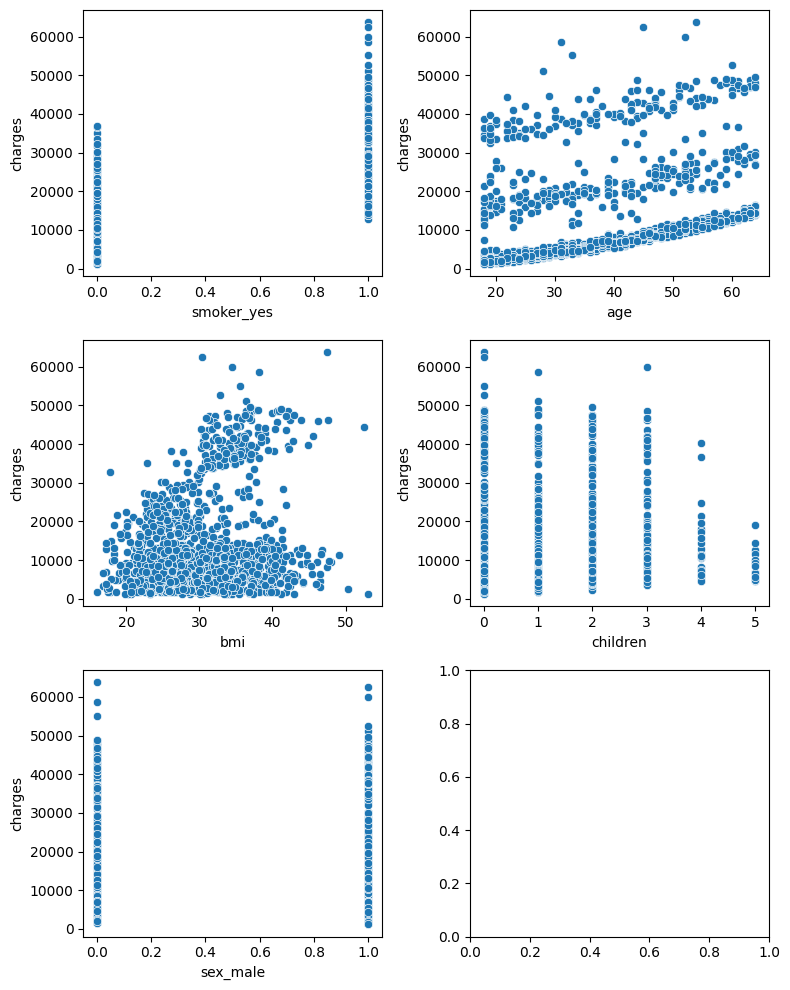

In [10]:
fig,axa=plt.subplots(3,2,figsize=(8,10))
sns.scatterplot(df,x='smoker_yes',y='charges',ax=axa[0][0])
sns.scatterplot(df,x='age',y='charges',ax=axa[0][1])
sns.scatterplot(df,x='bmi',y='charges',ax=axa[1][0])
sns.scatterplot(df,x='children',y='charges',ax=axa[1][1])
sns.scatterplot(df,x='sex_male',y='charges',ax=axa[2][0])
plt.tight_layout()
plt.show()

In [11]:
df.corr()

,age,bmi,children,charges,sex_male,smoker_yes
age,1.000000,0.109272,0.042469,0.299008,-0.020856,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.046371,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.017163,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.057292,0.787251
sex_male,-0.020856,0.046371,0.017163,0.057292,1.000000,0.076185
smoker_yes,-0.025019,0.003750,0.007673,0.787251,0.076185,1.000000


In [12]:
df.corr()['charges']

age           0.299008
bmi           0.198341
children      0.067998
charges       1.000000
sex_male      0.057292
smoker_yes    0.787251
Name: charges, dtype: float64

here charges and smoker_yes are having  linear relationship and also charges and age are having modarate relationship 
so we can use linear regression algorithm

In [13]:
x= df.drop('charges', axis=1)
y=df['charges']

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [16]:
m=LinearRegression()

In [17]:
m.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
m.intercept_

np.float64(-12113.451250917098)

In [19]:
y_perd=m.predict(xtest)
y_p=m.predict(xtrain)

In [20]:
m.score(xtrain,ytrain)

0.7410888590280913

In [21]:
m.score(xtest,ytest)

0.7811302113434095

In [22]:
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error

In [23]:
r2_score(ytrain,y_p)

0.7410888590280913

In [24]:
r2_score(ytest,y_perd)

0.7811302113434095

In [25]:
mean_squared_error(ytest,y_perd)

33979257.05080822

In [26]:
r=root_mean_squared_error(ytest,y_perd)

In [27]:
import numpy as np

In [28]:
target_mean=np.mean(ytest)

In [29]:
MSE_evaluation=r/target_mean

In [30]:
MSE_evaluation

np.float64(0.44949340010695354)